## Imports and Environment Setup
We import all required libraries, set plotting styles, and print library versions for reproducibility.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Set plotting styles
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

# Print library versions
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('matplotlib:', plt.matplotlib.__version__)
print('seaborn:', sns.__version__)
import sklearn
print('sklearn:', sklearn.__version__)

pandas: 2.3.3
numpy: 2.4.1
matplotlib: 3.10.8
seaborn: 0.13.2
sklearn: 1.8.0


## Load Data
We load the cleaned main dataset, check its shape, data types, and preview the first few rows. We also check for missing Brent price values.

In [14]:
# Load the main dataset
df = pd.read_csv('../main dataset/main_data_cleaned.csv')
print('Shape:', df.shape)
print('Data types:')
print(df.dtypes)
print('First 5 rows:')
print(df.head())
print('Nulls in Brent_Price_USD:', df['Brent_Price_USD'].isnull().sum())

Shape: (61152, 15)
Data types:
Year_Week                     object
year                           int64
location                      object
code                           int64
vegetable_type                object
price                        float64
no_of_holidays               float64
vegetable_zone               float64
seasonality                  float64
lanka_auto_diesel_price      float64
mean_apparent_temperature    float64
rain_sum                     float64
usd_exchange_rate            float64
week_num                       int64
Brent_Price_USD              float64
dtype: object
First 5 rows:
  Year_Week  year         location  code vegetable_type  price  \
0  2013-W01  2013  Thambuththegama   323        PUMPKIN   37.0   
1  2013-W01  2013            Kandy   323        PUMPKIN   42.0   
2  2013-W01  2013         Dambulla   323        PUMPKIN   48.0   
3  2013-W01  2013         Puttalam   323        PUMPKIN   52.0   
4  2013-W01  2013      Nuwaraeliya   323        PUMPKIN 

## Create and Sort by time_index
We create a `time_index` column (year * 100 + week_num) for easy chronological sorting and analysis.

In [15]:
# Create time_index
df['time_index'] = df['year'] * 100 + df['week_num']
df = df.sort_values('time_index').reset_index(drop=True)
print('Min time_index:', df['time_index'].min())
print('Max time_index:', df['time_index'].max())
print('First 3 rows:')
print(df.head(3))
print('Last 3 rows:')
print(df.tail(3))

Min time_index: 201301
Max time_index: 201952
First 3 rows:
  Year_Week  year         location  code vegetable_type  price  \
0  2013-W01  2013  Thambuththegama   323        PUMPKIN   37.0   
1  2013-W01  2013            Kandy   323        PUMPKIN   42.0   
2  2013-W01  2013         Dambulla   323        PUMPKIN   48.0   

   no_of_holidays  vegetable_zone  seasonality  lanka_auto_diesel_price  \
0             NaN             NaN          NaN                    115.0   
1             NaN             NaN          NaN                    115.0   
2             NaN             NaN          NaN                    115.0   

   mean_apparent_temperature  rain_sum  usd_exchange_rate  week_num  \
0                        NaN       NaN           127.0721         1   
1                        NaN       NaN           127.0721         1   
2                        NaN       NaN           127.0721         1   

   Brent_Price_USD  time_index  
0          112.828      201301  
1          112.828     

## Create Brent_Price_LKR
We multiply Brent price in USD by the USD/LKR exchange rate to get the true local cost. This reflects both global price changes and currency fluctuations.

Brent_Price_LKR stats:
count    61152.000000
mean     10250.817794
std       2967.307301
min       3946.829171
25%       7529.258149
50%      10627.417481
75%      12868.966342
max      15390.932700
Name: Brent_Price_LKR, dtype: float64


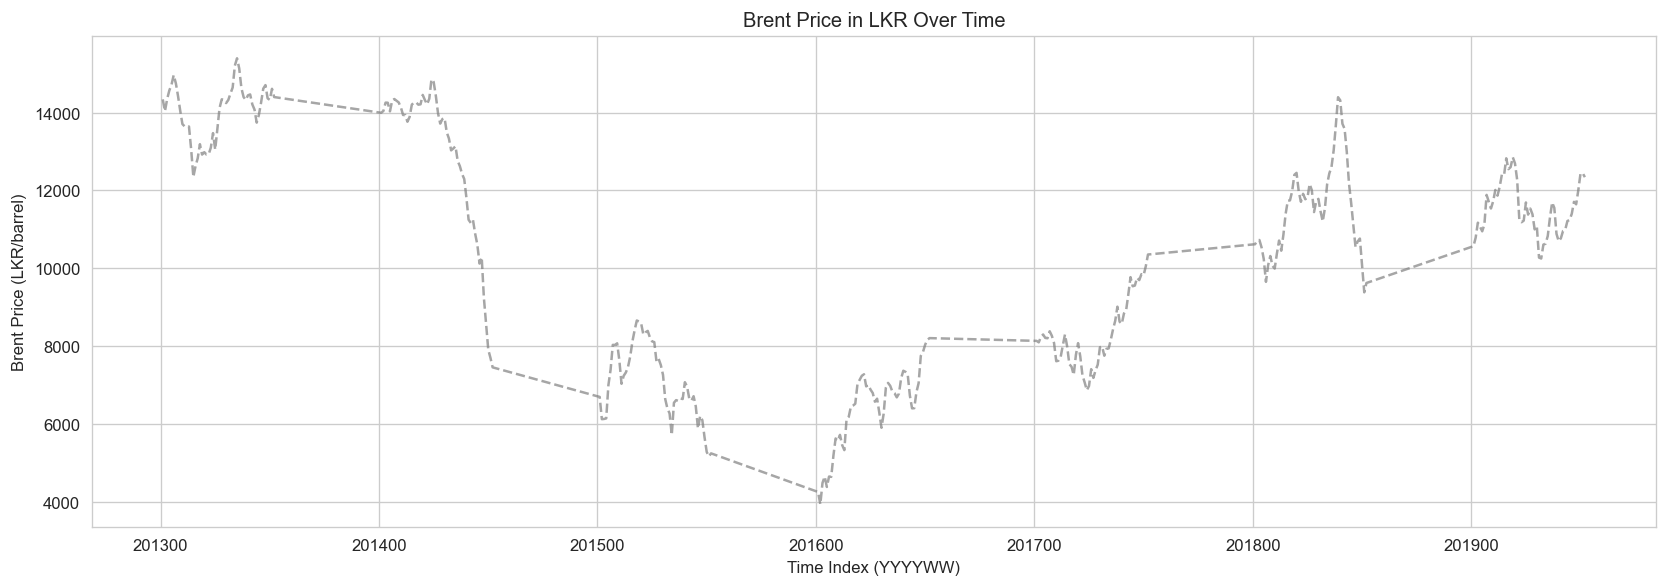

In [16]:
# Calculate Brent price in LKR
df['Brent_Price_LKR'] = df['Brent_Price_USD'] * df['usd_exchange_rate']
desc = df['Brent_Price_LKR'].describe()
print('Brent_Price_LKR stats:')
print(desc)
# Plot Brent_Price_LKR trend (one row per week)
brent_lkr_trend = df.drop_duplicates('time_index')[['time_index', 'Brent_Price_LKR']].sort_values('time_index')
plt.figure(figsize=(14,5))
plt.plot(brent_lkr_trend['time_index'], brent_lkr_trend['Brent_Price_LKR'], color='grey', linestyle='--', alpha=0.7)
plt.title('Brent Price in LKR Over Time')
plt.xlabel('Time Index (YYYYWW)')
plt.ylabel('Brent Price (LKR/barrel)')
plt.tight_layout()
plt.savefig('brent_lkr_trend.png', dpi=150)
plt.show()

## Filter Data for Meegoda
We focus on Meegoda market and four key vegetables. Nulls are dropped to ensure clean analysis.

In [17]:
veg_list = ['CARROT', 'PUMPKIN', 'BRINJALS', 'BEETROOT']
df_meegoda = df[(df['location'] == 'Meegoda') &
                 (df['vegetable_type'].isin(veg_list)) &
                 (~df['price'].isnull()) &
                 (~df['Brent_Price_LKR'].isnull())]
print('Meegoda filtered shape:', df_meegoda.shape)
print('Vegetable counts:')
print(df_meegoda['vegetable_type'].value_counts())

Meegoda filtered shape: (1428, 17)
Vegetable counts:
vegetable_type
PUMPKIN     357
BEETROOT    357
BRINJALS    357
CARROT      357
Name: count, dtype: int64


## Weekly Aggregation for Meegoda
We aggregate by week and vegetable, taking the mean price and the first Brent price per week.

In [18]:
df_meegoda_weekly = df_meegoda.groupby(['time_index', 'vegetable_type']).agg({
    'price': 'mean',
    'Brent_Price_LKR': 'first'
}).reset_index().sort_values(['time_index', 'vegetable_type']).reset_index(drop=True)

print('Weekly aggregated shape:', df_meegoda_weekly.shape)
print(df_meegoda_weekly.head(10))

Weekly aggregated shape: (1428, 4)
   time_index vegetable_type  price  Brent_Price_LKR
0      201301       BEETROOT  132.0     14337.290899
1      201301       BRINJALS  135.0     14337.290899
2      201301         CARROT  156.0     14337.290899
3      201301        PUMPKIN   57.5     14337.290899
4      201302       BEETROOT  180.0     14033.169634
5      201302       BRINJALS  197.5     14033.169634
6      201302         CARROT  192.0     14033.169634
7      201302        PUMPKIN   55.0     14033.169634
8      201303       BEETROOT  180.0     14343.923993
9      201303       BRINJALS  195.0     14343.923993


## Normalize Prices for Meegoda
Normalization puts all series on a 0–1 scale, so we can compare trends and co-movements visually and statistically.

In [19]:
# Normalize price per vegetable
df_meegoda_weekly['price_normalized'] = np.nan
scaler_brent = MinMaxScaler()
df_meegoda_weekly['brent_normalized'] = scaler_brent.fit_transform(df_meegoda_weekly[['Brent_Price_LKR']])
for veg in veg_list:
    idx = df_meegoda_weekly['vegetable_type'] == veg
    scaler = MinMaxScaler()
    df_meegoda_weekly.loc[idx, 'price_normalized'] = scaler.fit_transform(df_meegoda_weekly.loc[idx, ['price']])
# Check normalization
print('price_normalized min/max:', df_meegoda_weekly['price_normalized'].min(), df_meegoda_weekly['price_normalized'].max())
print('brent_normalized min/max:', df_meegoda_weekly['brent_normalized'].min(), df_meegoda_weekly['brent_normalized'].max())

price_normalized min/max: 0.0 1.0
brent_normalized min/max: 0.0 0.9999999999999999


## Dual-Axis Line Chart — Meegoda
We plot normalized vegetable prices and normalized Brent price together for each vegetable to visually compare their trends.

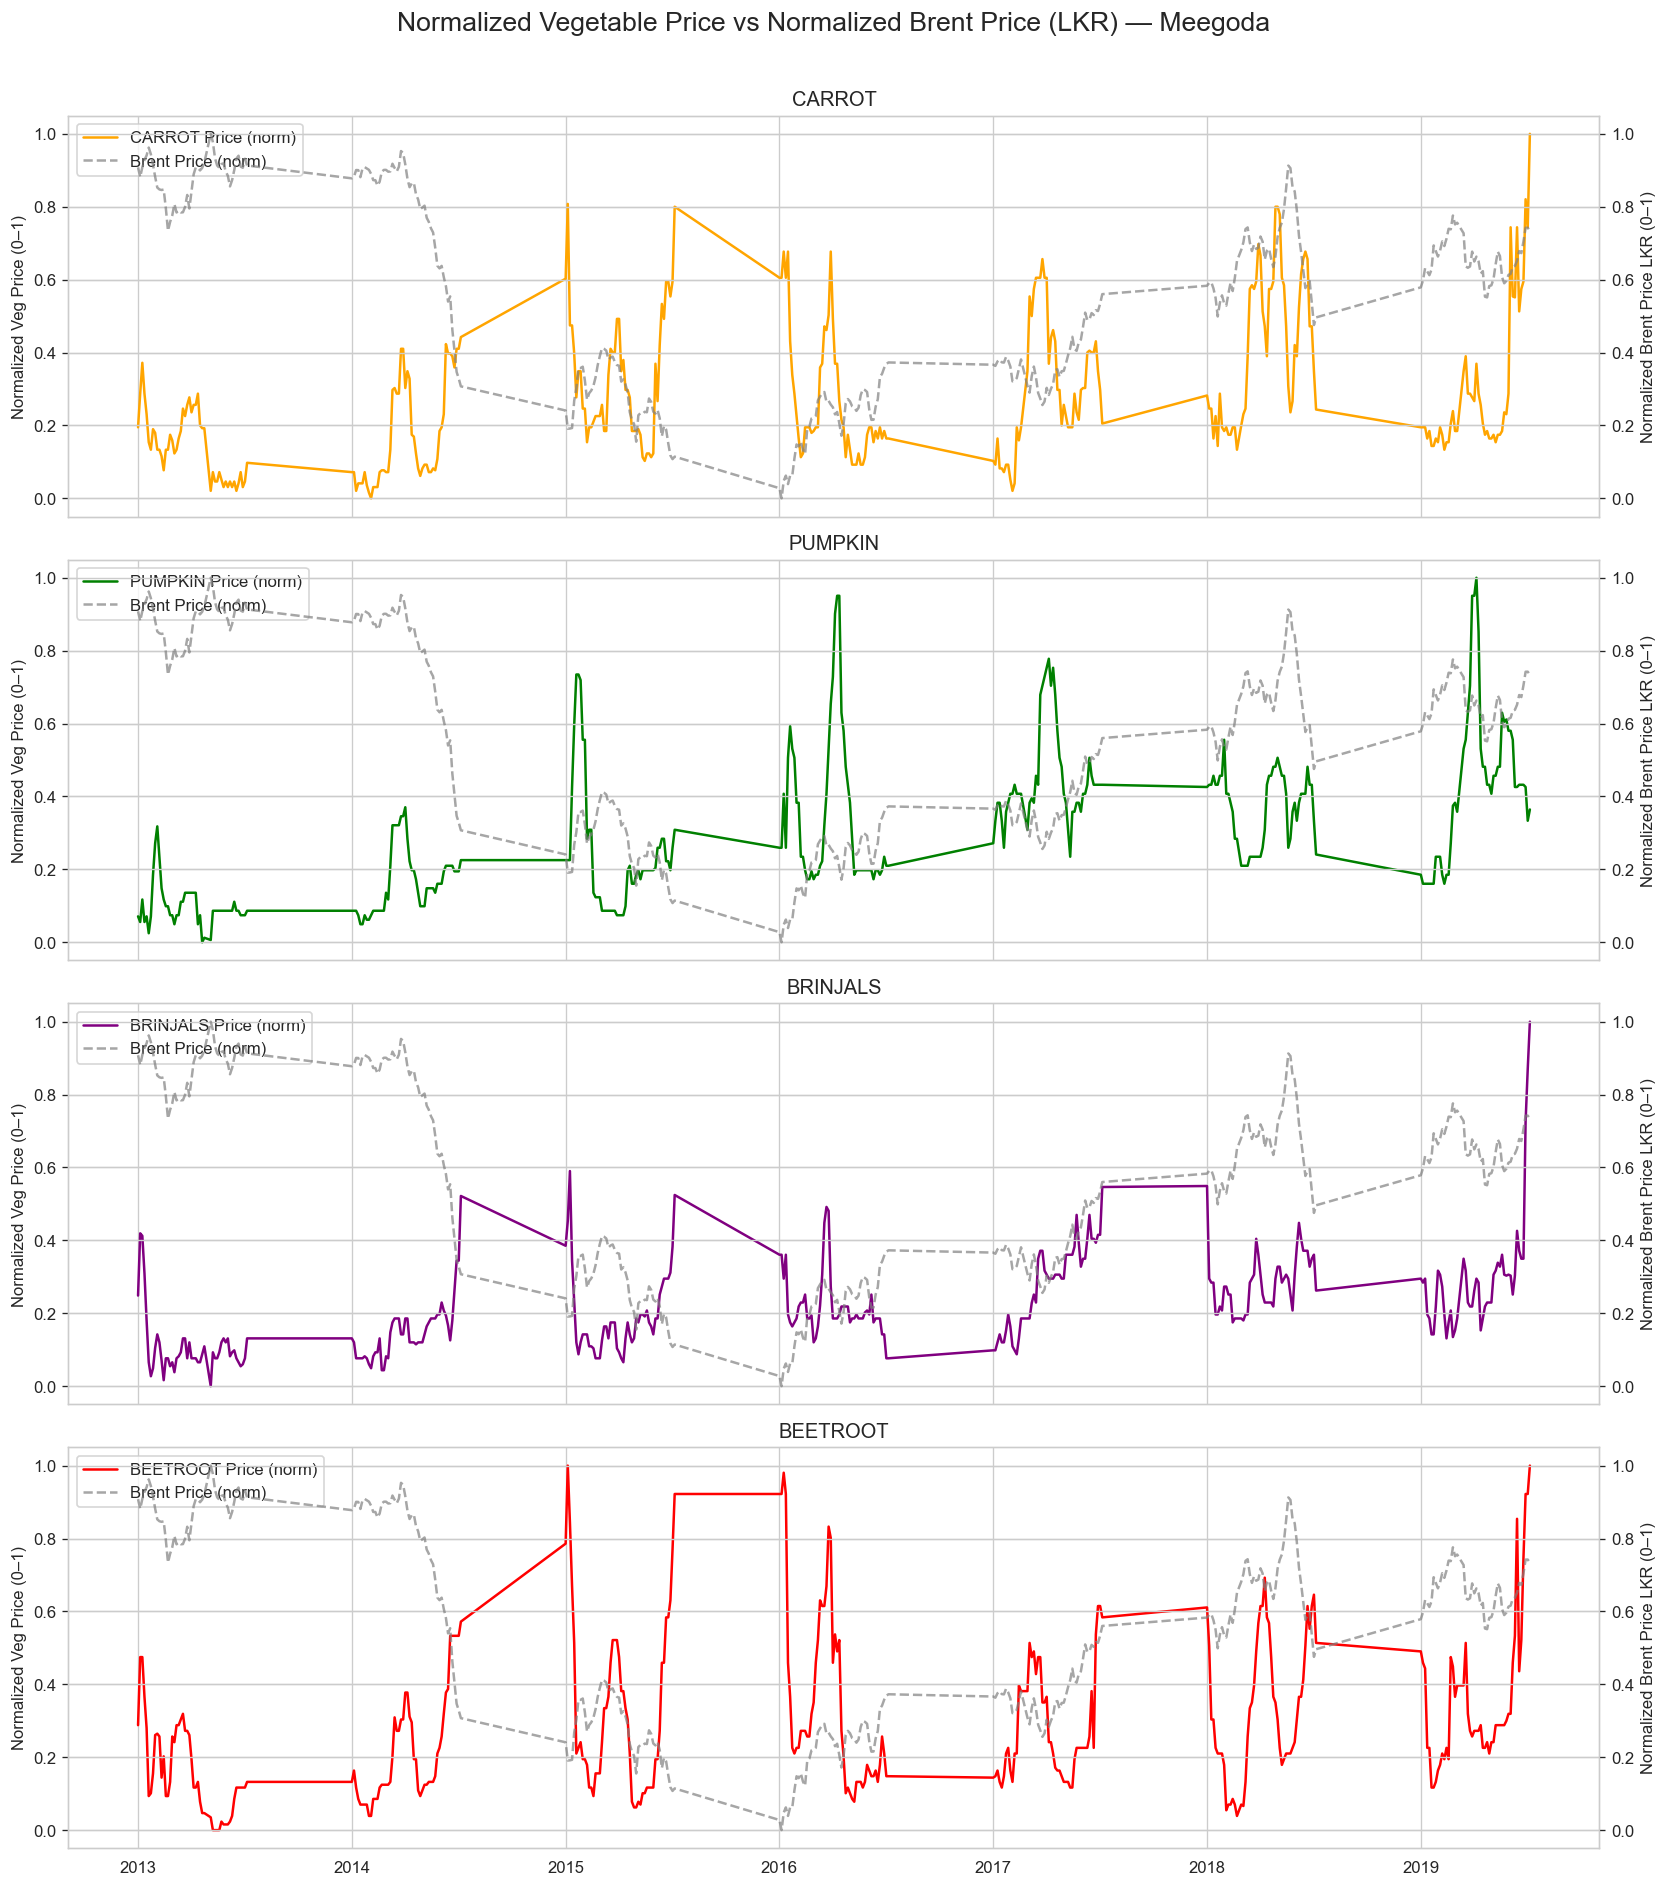

In [20]:
color_map = {'CARROT': 'orange', 'PUMPKIN': 'green', 'BRINJALS': 'purple', 'BEETROOT': 'red'}
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
for i, veg in enumerate(veg_list):
    ax = axes[i]
    data = df_meegoda_weekly[df_meegoda_weekly['vegetable_type'] == veg]
    ax.plot(data['time_index'], data['price_normalized'], color=color_map[veg], label=f'{veg} Price (norm)')
    ax.set_ylabel('Normalized Veg Price (0–1)')
    ax2 = ax.twinx()
    ax2.plot(data['time_index'], data['brent_normalized'], color='grey', linestyle='--', alpha=0.7, label='Brent Price (norm)')
    ax2.set_ylabel('Normalized Brent Price LKR (0–1)')
    ax.set_title(veg)
    # Legend
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper left')
    # Year ticks
    year_ticks = data[data['time_index'] % 100 == 1]['time_index']
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([str(t)[:4] for t in year_ticks])
fig.suptitle('Normalized Vegetable Price vs Normalized Brent Price (LKR) — Meegoda', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('plot1_brent_dual_axis_meegoda.png', dpi=150)
plt.show()

## Scatter Plot with Regression Lines — Meegoda
We plot normalized Brent price vs normalized vegetable price for each vegetable, fit regression lines, and show correlation coefficients.

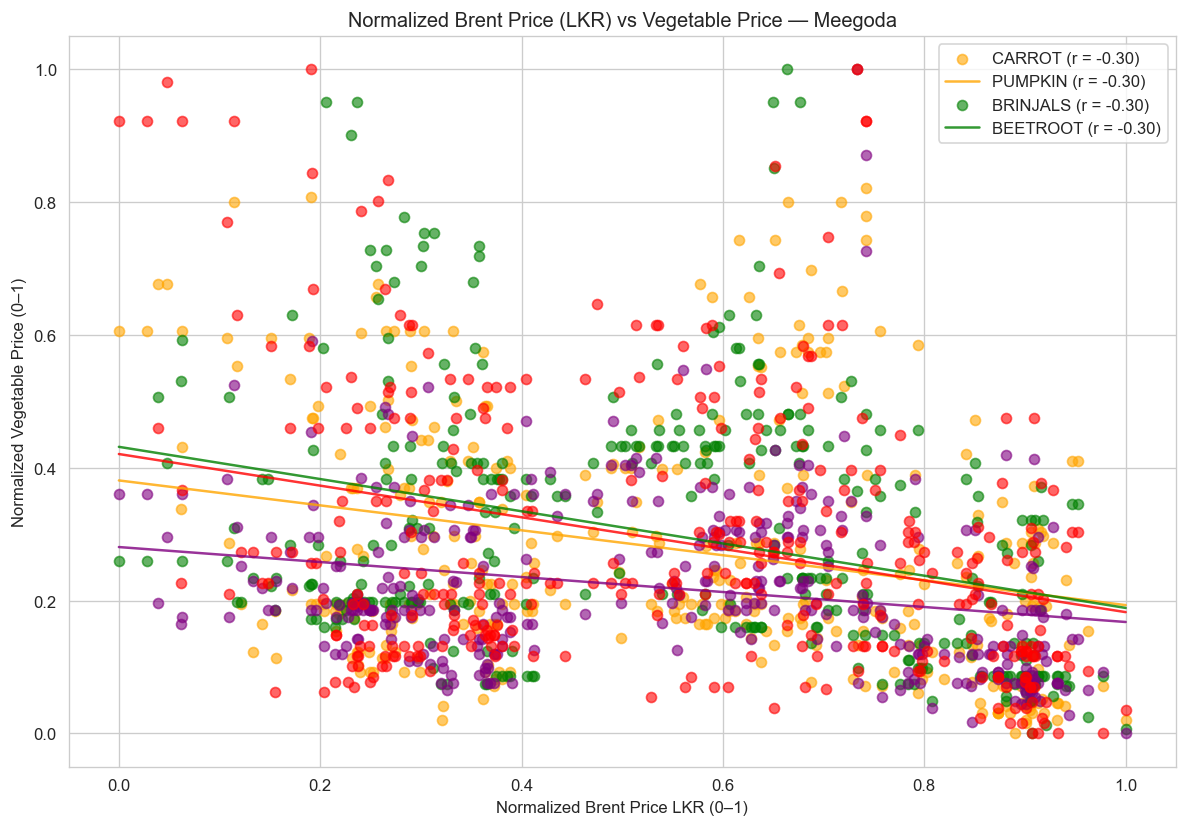

In [21]:
plt.figure(figsize=(10, 7))
for veg in veg_list:
    data = df_meegoda_weekly[df_meegoda_weekly['vegetable_type'] == veg]
    plt.scatter(data['brent_normalized'], data['price_normalized'], color=color_map[veg], alpha=0.6, label=veg)
    # Regression line
    if len(data) > 1:
        coef = np.polyfit(data['brent_normalized'], data['price_normalized'], 1)
        x = np.linspace(0, 1, 100)
        y = coef[0] * x + coef[1]
        plt.plot(x, y, color=color_map[veg], linestyle='-', alpha=0.8)
    # Pearson r
    r = np.corrcoef(data['brent_normalized'], data['price_normalized'])[0, 1]
    plt.legend([f'{veg} (r = {r:.2f})' for veg in veg_list])
plt.xlabel('Normalized Brent Price LKR (0–1)')
plt.ylabel('Normalized Vegetable Price (0–1)')
plt.title('Normalized Brent Price (LKR) vs Vegetable Price — Meegoda')
plt.tight_layout()
plt.savefig('plot2_brent_scatter_meegoda.png', dpi=150)
plt.show()

## Correlation Heatmap — Meegoda (All Vegetables)
We compute and visualize the correlation matrix for all Meegoda vegetables, Brent price, and USD rate.

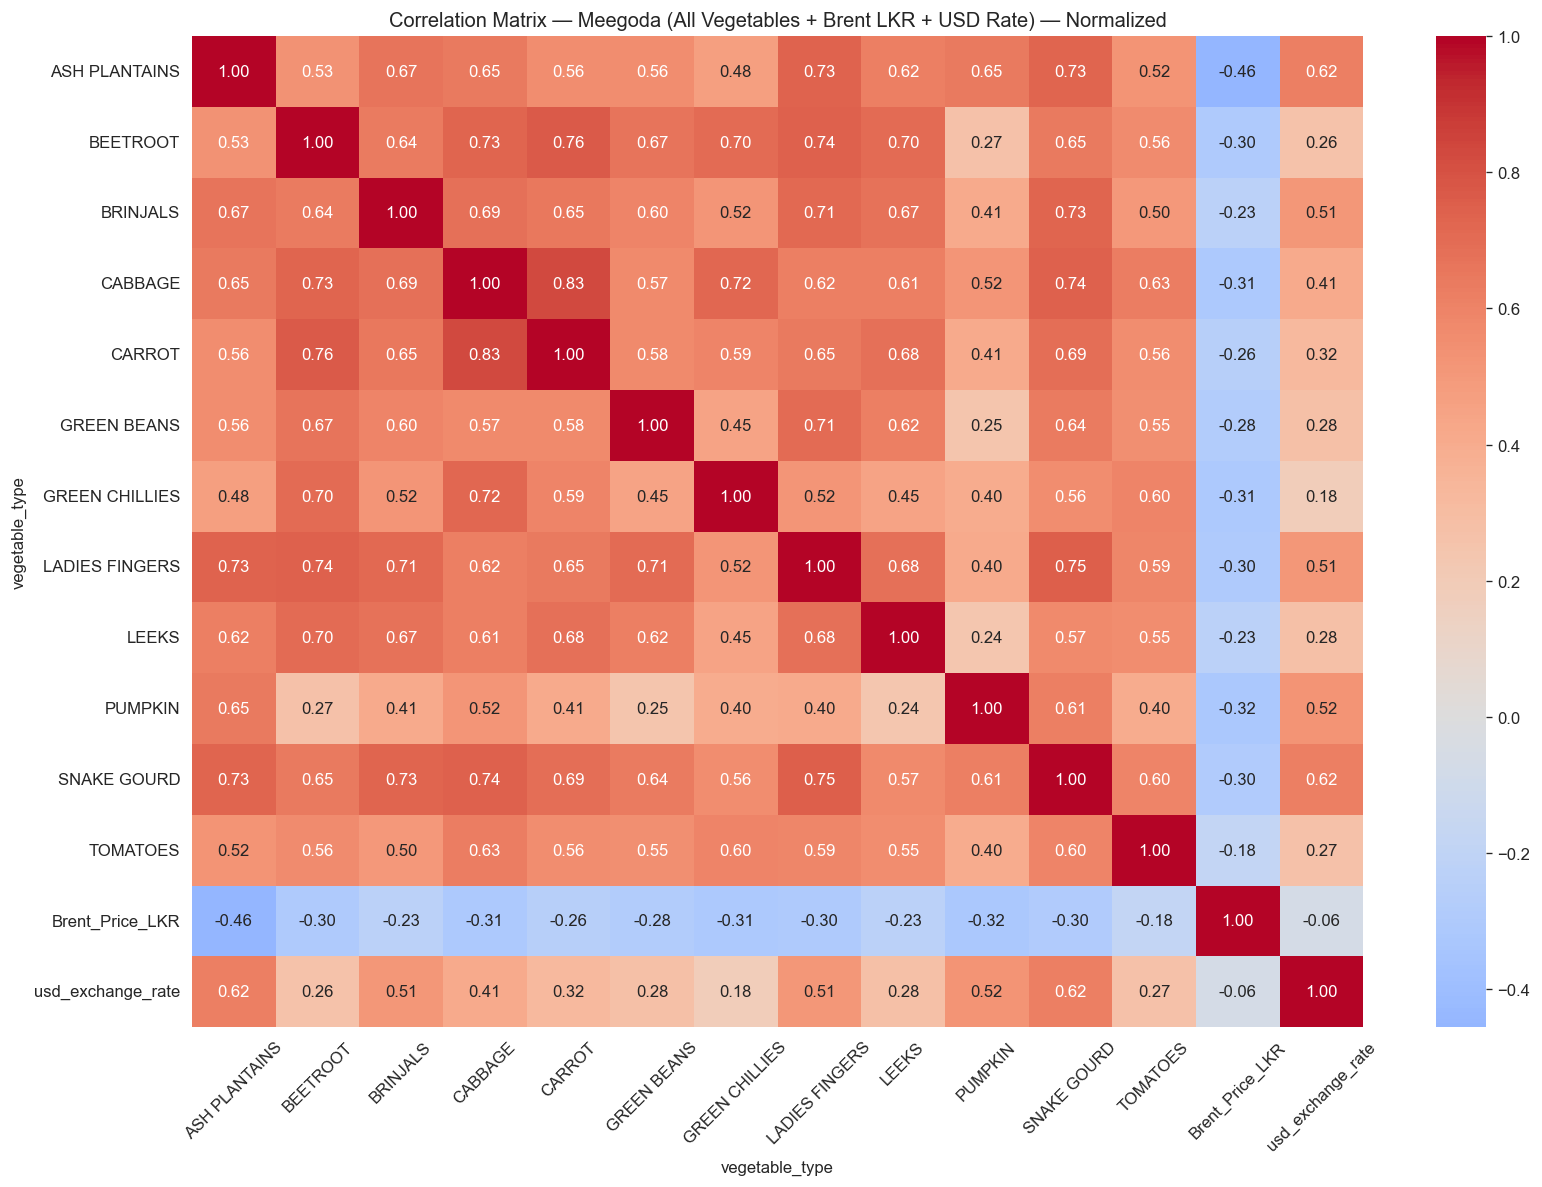

In [22]:
# Prepare data
df_meegoda_all = df[(df['location'] == 'Meegoda') &
                    (~df['price'].isnull()) &
                    (~df['Brent_Price_LKR'].isnull())]
pivot = df_meegoda_all.groupby(['time_index', 'vegetable_type'])['price'].mean().unstack()
# Normalize each column
scaler = MinMaxScaler()
pivot_norm = pd.DataFrame(scaler.fit_transform(pivot.fillna(0)), columns=pivot.columns, index=pivot.index)
# Merge normalized Brent and USD
brent_usd = df_meegoda_all.drop_duplicates('time_index')[['time_index', 'Brent_Price_LKR', 'usd_exchange_rate']].set_index('time_index')
pivot_norm['Brent_Price_LKR'] = scaler.fit_transform(brent_usd['Brent_Price_LKR'].values.reshape(-1, 1))
pivot_norm['usd_exchange_rate'] = scaler.fit_transform(brent_usd['usd_exchange_rate'].values.reshape(-1, 1))
corr = pivot_norm.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Meegoda (All Vegetables + Brent LKR + USD Rate) — Normalized')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot3_brent_correlation_heatmap_meegoda.png', dpi=150)
plt.show()

## Correlation Summary — Meegoda
We print the Pearson correlation between each vegetable's normalized price and normalized Brent price, and compare with diesel price correlation.

In [24]:
for veg in veg_list:
    data = df_meegoda_weekly[df_meegoda_weekly['vegetable_type'] == veg]
    r_brent = np.corrcoef(data['brent_normalized'], data['price_normalized'])[0, 1]
    # Diesel normalization (per veg, per week)
    diesel_vals = df_meegoda[df_meegoda['vegetable_type'] == veg].groupby('time_index')['lanka_auto_diesel_price'].first().reindex(data['time_index']).values
    scaler_diesel = MinMaxScaler()
    diesel_norm = scaler_diesel.fit_transform(diesel_vals.reshape(-1, 1)).flatten()
    price_norm = data['price_normalized'].values
    r_diesel = np.corrcoef(diesel_norm, price_norm)[0, 1]
    print(f'{veg}: Brent r = {r_brent:.2f}, Diesel r = {r_diesel:.2f}')
    # Interpretation
    if abs(r_brent) < 0.2:
        interp = 'very weak'
    elif abs(r_brent) < 0.4:
        interp = 'weak'
    elif abs(r_brent) < 0.6:
        interp = 'moderate'
    elif abs(r_brent) < 0.8:
        interp = 'strong'
    else:
        interp = 'very strong'
    direction = 'positive' if r_brent > 0 else 'negative'
    print(f'  Brent correlation is {interp} and {direction}.')
    print()

CARROT: Brent r = -0.26, Diesel r = -0.20
  Brent correlation is weak and negative.

PUMPKIN: Brent r = -0.32, Diesel r = -0.43
  Brent correlation is weak and negative.

BRINJALS: Brent r = -0.23, Diesel r = -0.30
  Brent correlation is weak and negative.

BEETROOT: Brent r = -0.30, Diesel r = -0.22
  Brent correlation is weak and negative.



## Repeat for Colombo, Kandy, Dambulla
We repeat the dual-axis normalized plot for the other three main markets. For each, we filter, aggregate, normalize, and plot vegetable prices and Brent price together.

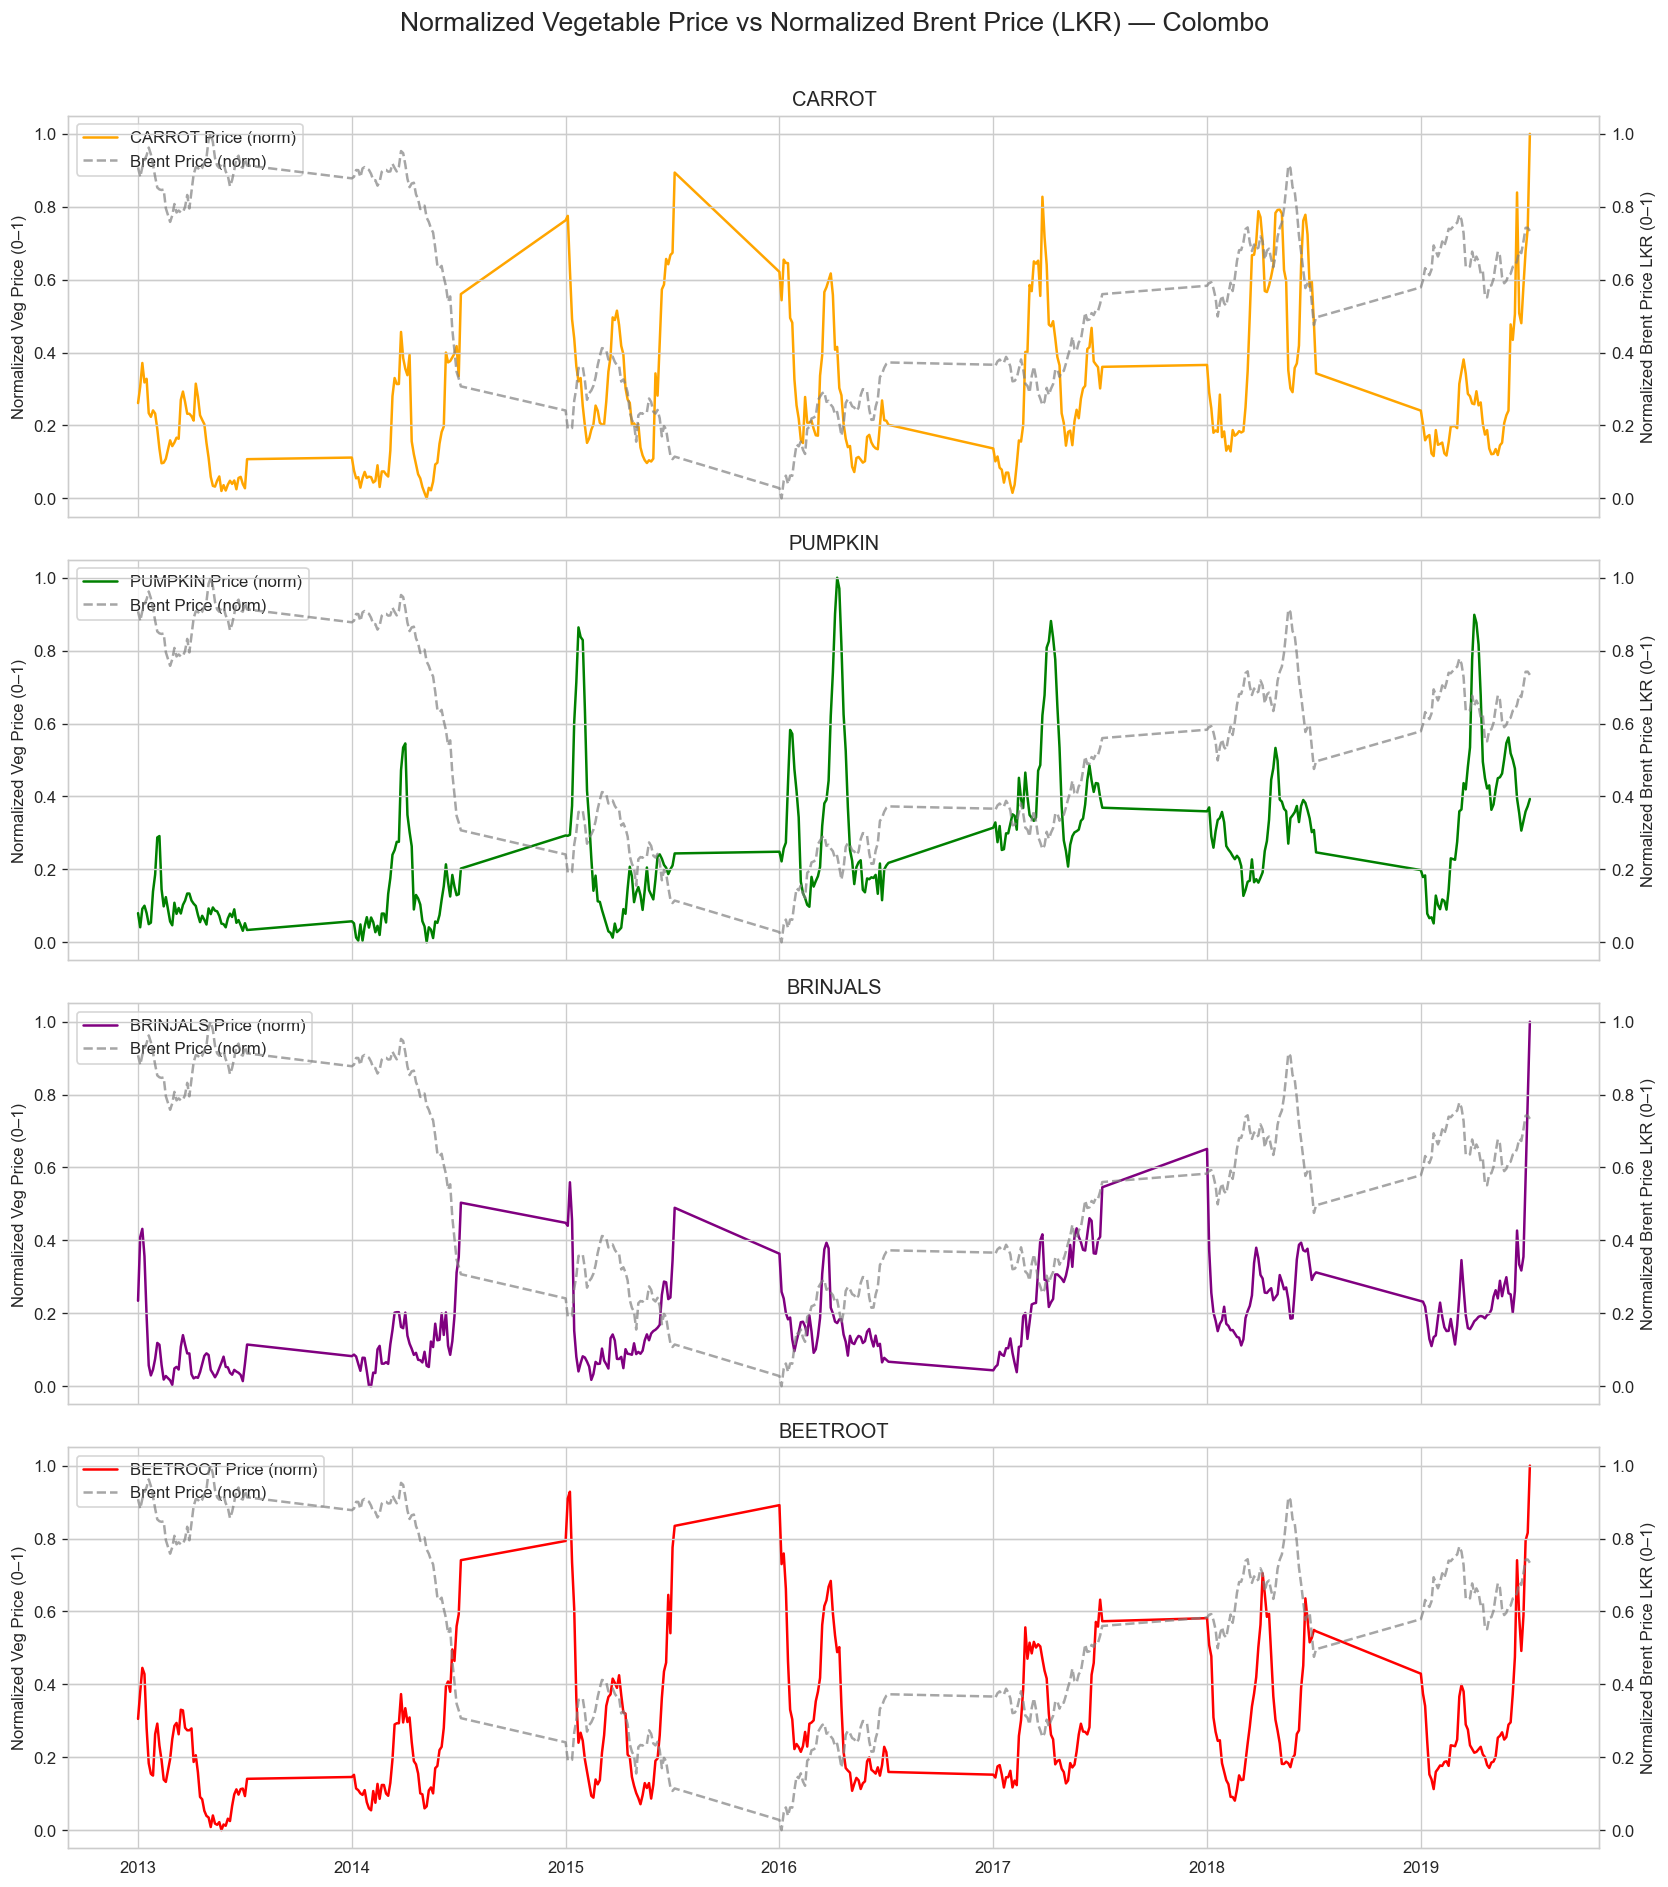

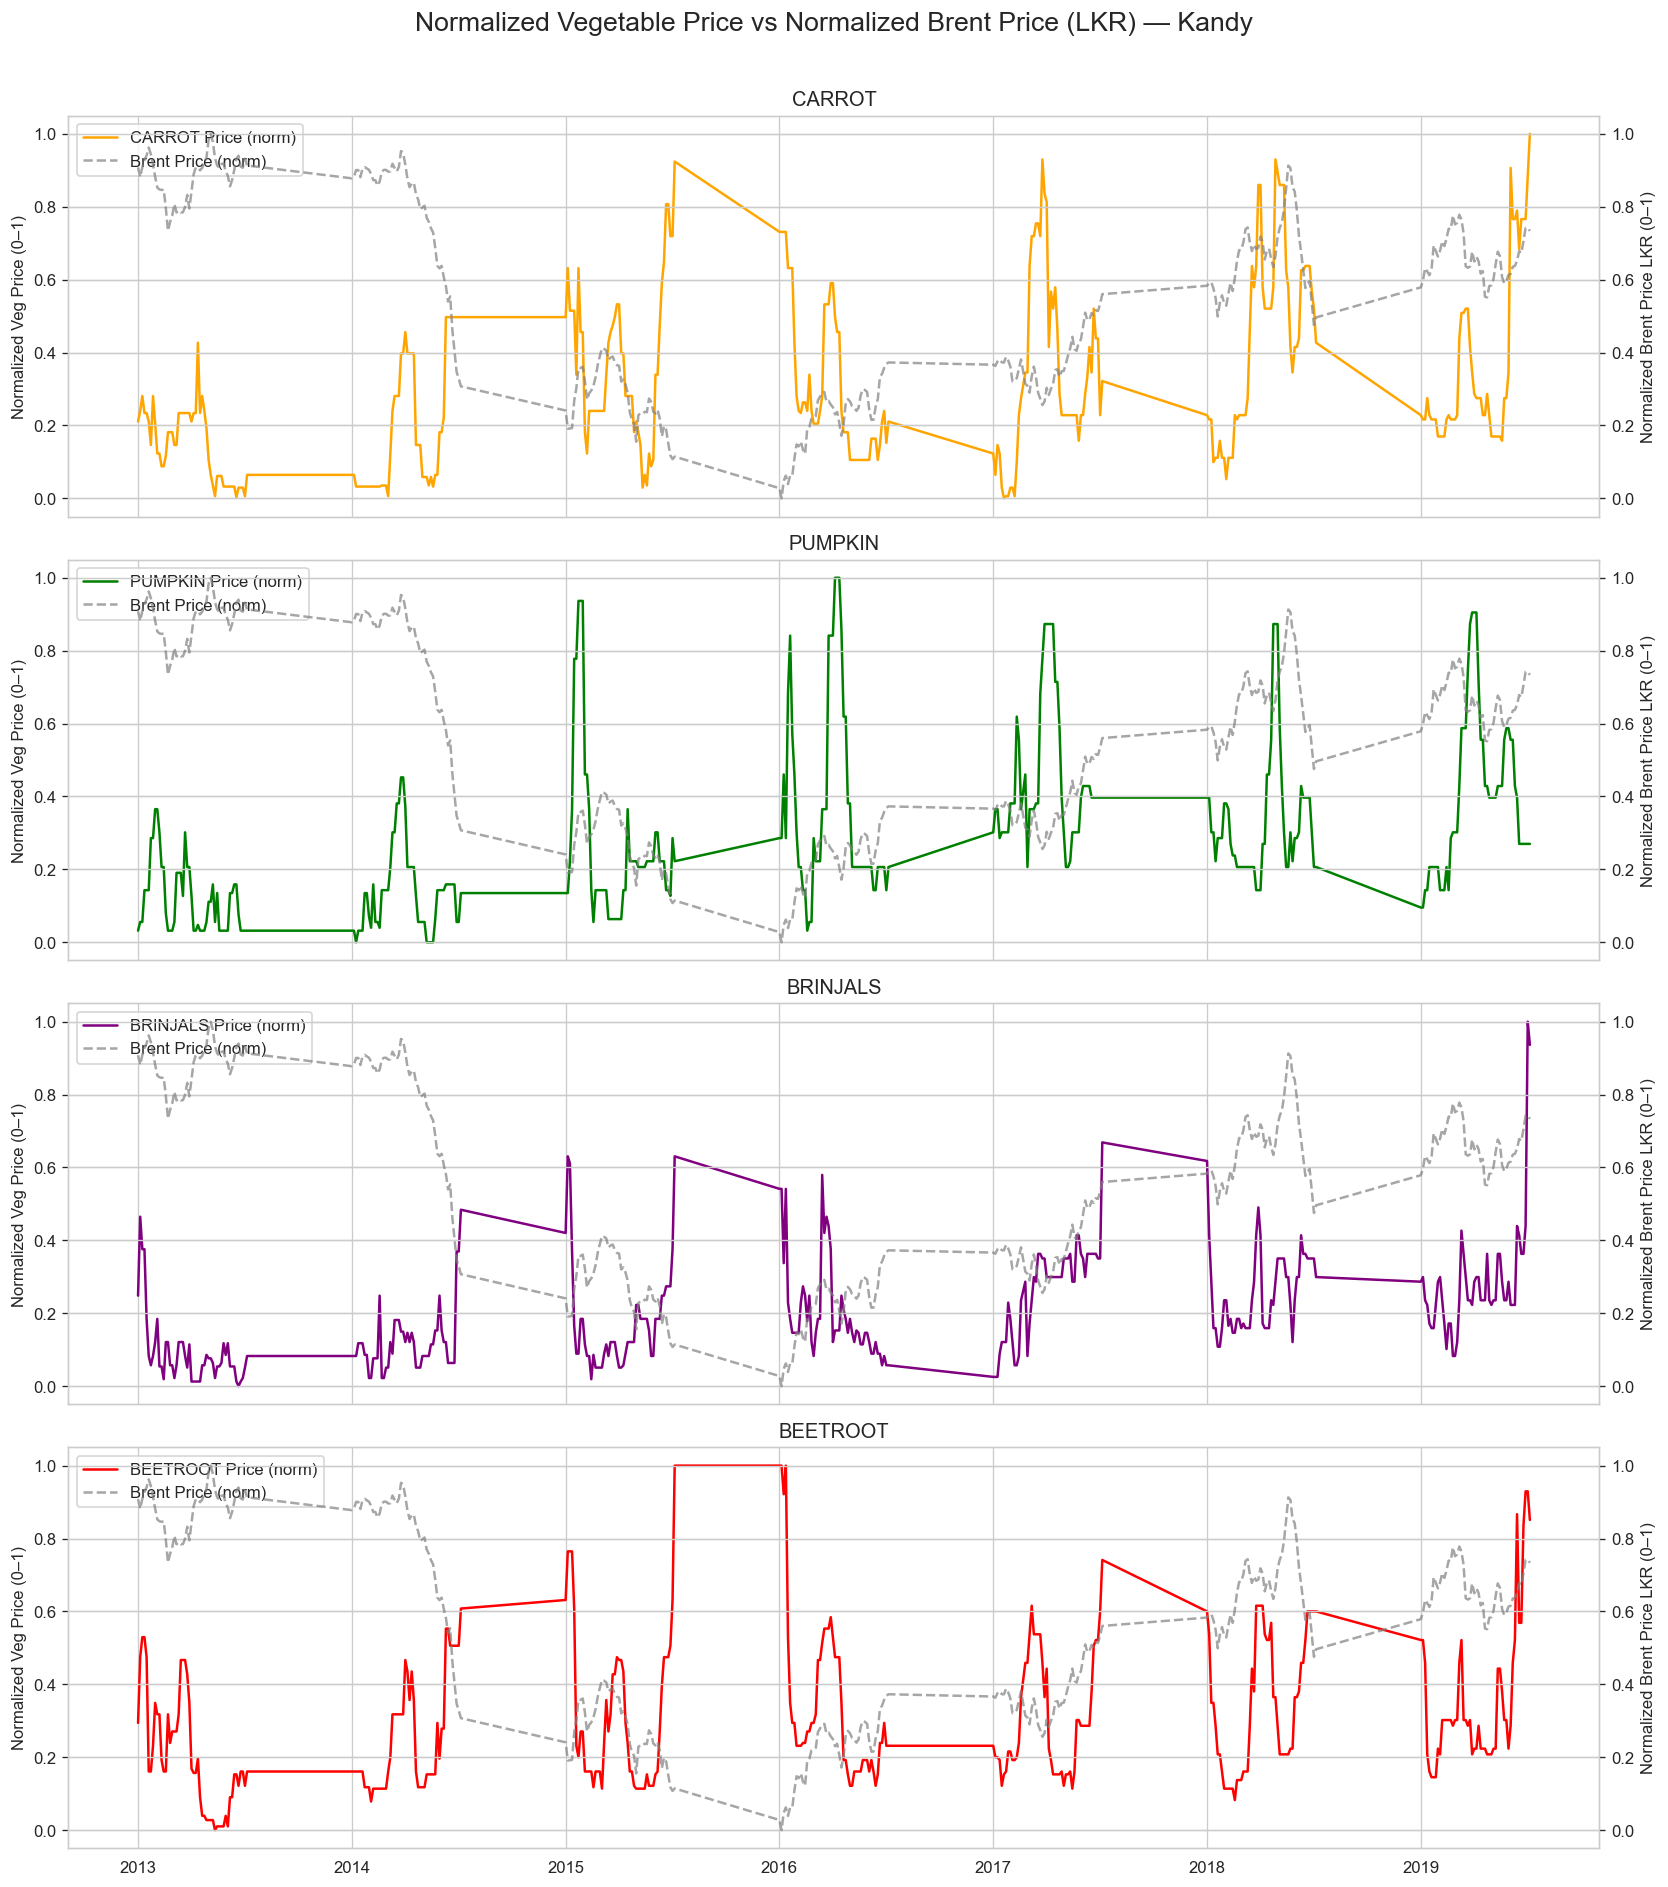

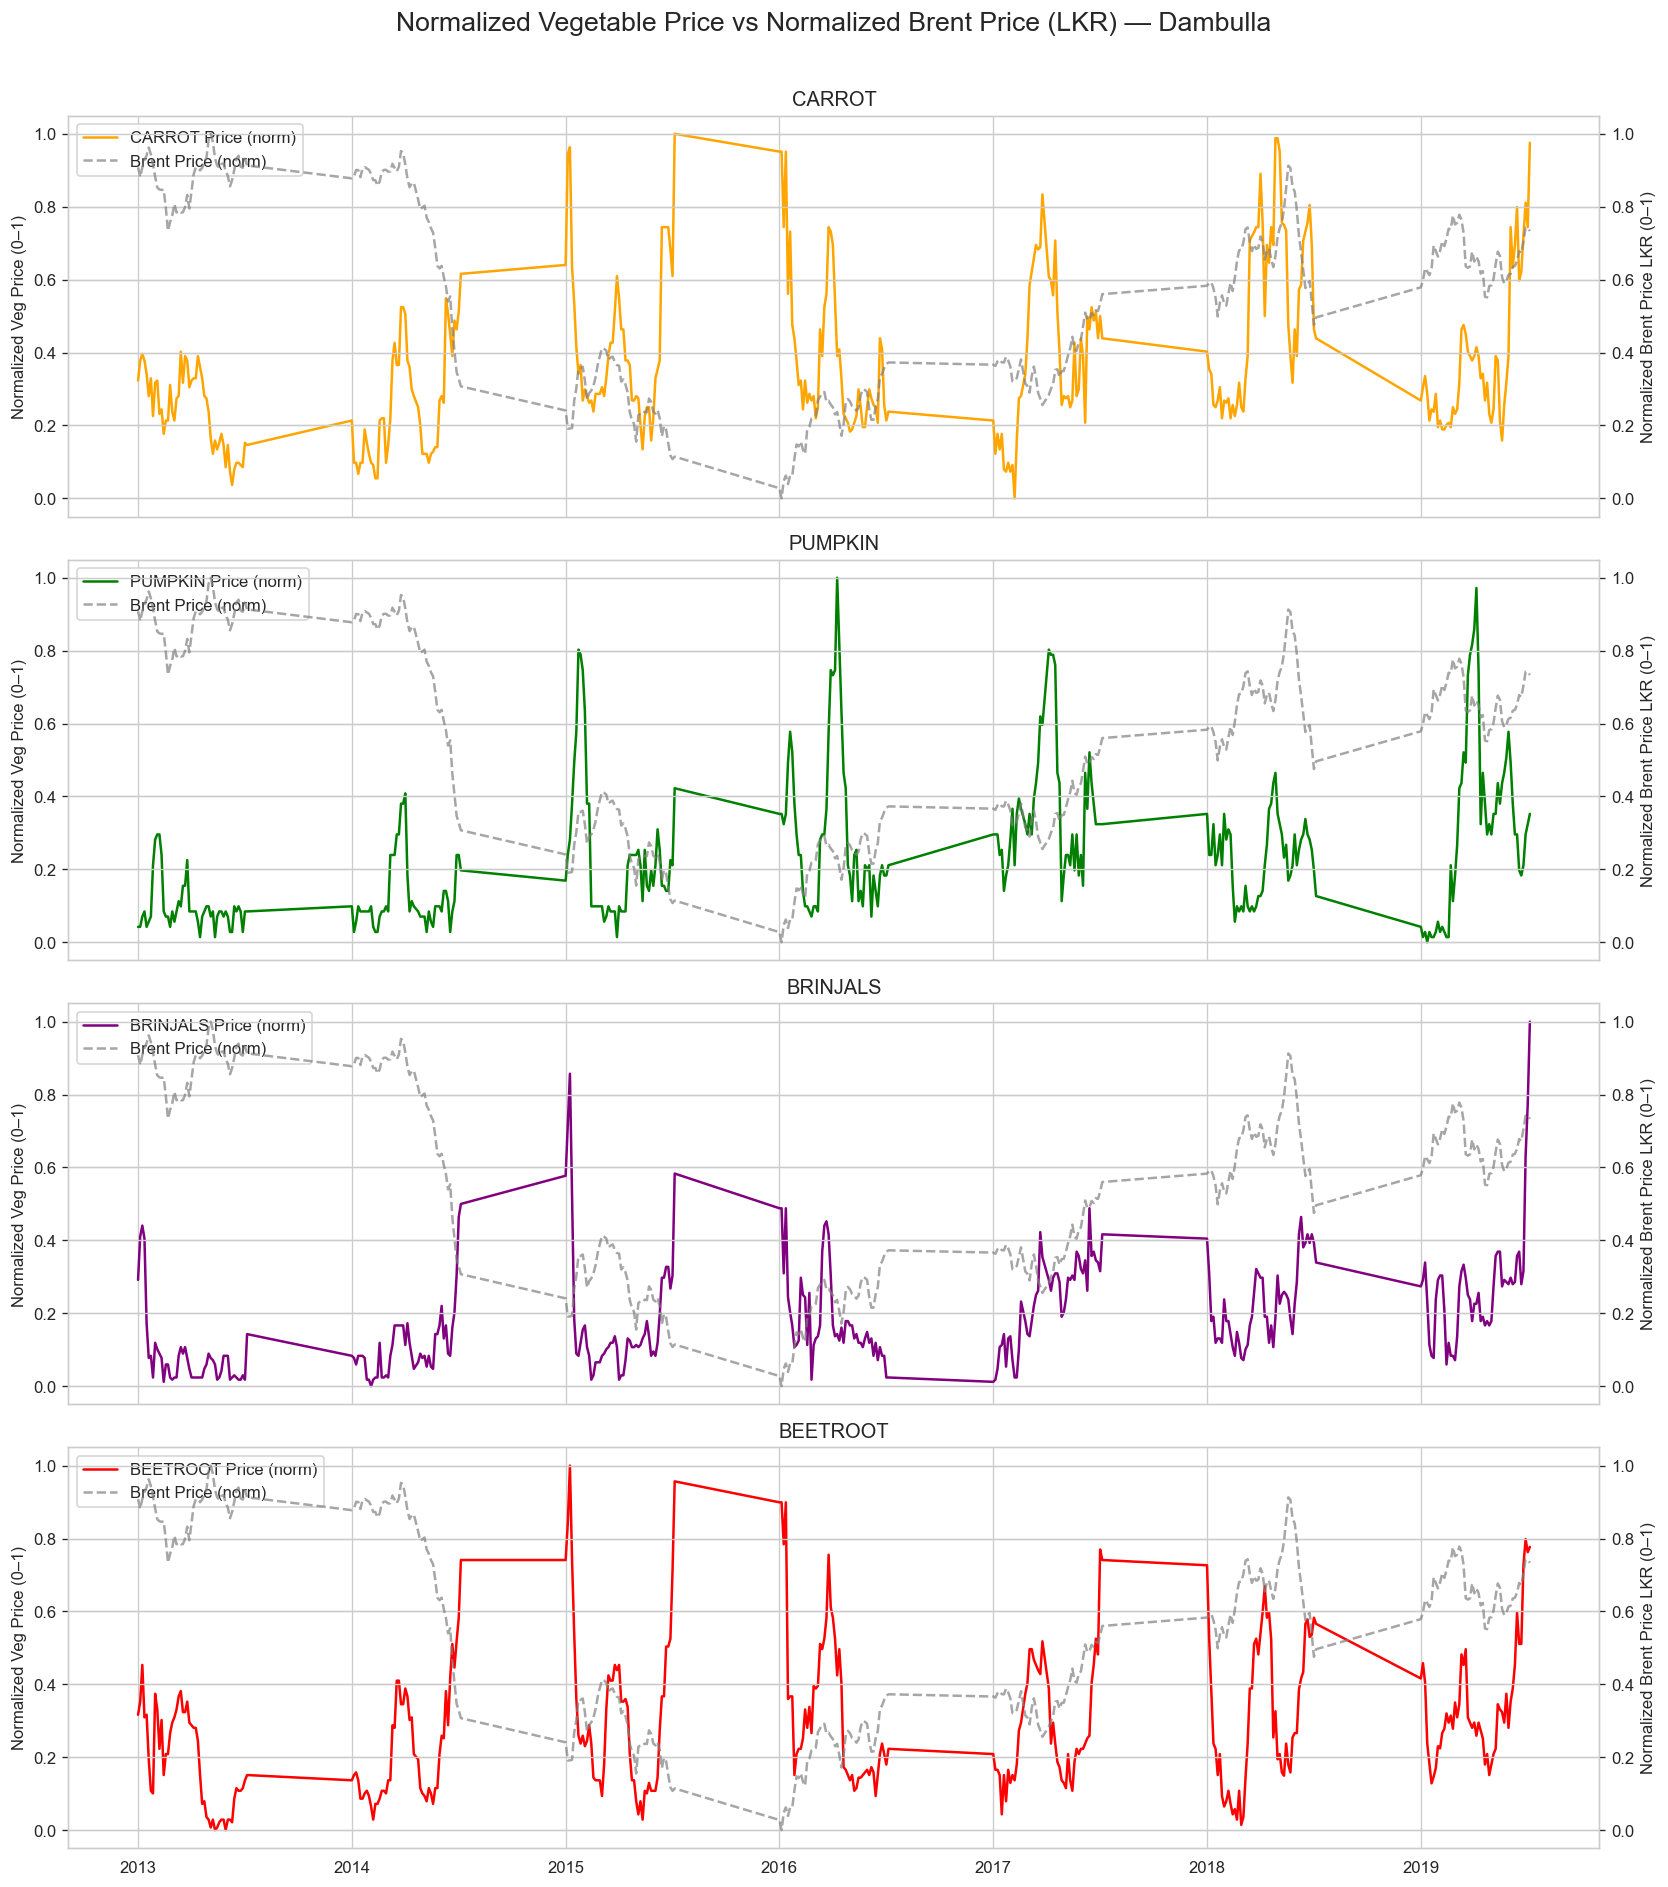

In [26]:
locations = ['Colombo', 'Kandy', 'Dambulla']
for i, loc in enumerate(locations):
    df_loc = df[(df['location'] == loc) &
                (df['vegetable_type'].isin(veg_list)) &
                (~df['price'].isnull()) &
                (~df['Brent_Price_LKR'].isnull())]
    df_loc_weekly = df_loc.groupby(['time_index', 'vegetable_type']).agg({
        'price': 'mean',
        'Brent_Price_LKR': 'first'
    }).reset_index().sort_values(['time_index', 'vegetable_type']).reset_index(drop=True)
    df_loc_weekly['price_normalized'] = np.nan
    scaler_brent = MinMaxScaler()
    df_loc_weekly['brent_normalized'] = scaler_brent.fit_transform(df_loc_weekly[['Brent_Price_LKR']])
    for veg in veg_list:
        idx = df_loc_weekly['vegetable_type'] == veg
        scaler = MinMaxScaler()
        df_loc_weekly.loc[idx, 'price_normalized'] = scaler.fit_transform(df_loc_weekly.loc[idx, ['price']])
    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
    for j, veg in enumerate(veg_list):
        ax = axes[j]
        data = df_loc_weekly[df_loc_weekly['vegetable_type'] == veg]
        ax.plot(data['time_index'], data['price_normalized'], color=color_map[veg], label=f'{veg} Price (norm)')
        ax.set_ylabel('Normalized Veg Price (0–1)')
        ax2 = ax.twinx()
        ax2.plot(data['time_index'], data['brent_normalized'], color='grey', linestyle='--', alpha=0.7, label='Brent Price (norm)')
        ax2.set_ylabel('Normalized Brent Price LKR (0–1)')
        ax.set_title(veg)
        lines, labels = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines + lines2, labels + labels2, loc='upper left')
        year_ticks = data[data['time_index'] % 100 == 1]['time_index']
        ax.set_xticks(year_ticks)
        ax.set_xticklabels([str(t)[:4] for t in year_ticks])
    fig.suptitle(f'Normalized Vegetable Price vs Normalized Brent Price (LKR) — {loc}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    fname = f'plot4_brent_dual_axis_colombo.png' if loc == 'Colombo' else (f'plot5_brent_dual_axis_kandy.png' if loc == 'Kandy' else f'plot6_brent_dual_axis_dambulla.png')
    plt.savefig(fname, dpi=150)
    plt.show()

# Brent Crude Price (LKR) vs Vegetable Price Analysis

This notebook explores the relationship between global Brent crude oil prices and Sri Lankan vegetable prices.

- **Why Brent instead of diesel?** Brent is the global benchmark for oil, while local diesel prices are often regulated and lag behind real market changes.
- **Why convert to LKR?** Oil is traded in USD, but Sri Lanka pays in LKR, so both the global price and the exchange rate affect local costs.
- **Why normalize?** Brent (LKR/barrel) and vegetables (LKR/kg) are on very different scales. Normalization lets us compare trends and co-movements.
- **Goal:** To see if and how global oil price shocks (in LKR) are reflected in local vegetable prices, and whether Brent or diesel is a better predictor.

---

**Notebook complete.**

You can now run each cell in order to reproduce the full Brent vs Vegetable Price analysis for Meegoda, Colombo, Kandy, and Dambulla.